In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXEFENjk4LWdlbmVyYXRpdmUtYWktZm9yLUJBXE0w'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\importlib\\_bootstrap.py": 1772917703.8481817, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\importlib\\_bootstrap_external.py": 1772917703.8490603, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\zipimport.py": 1772917704.7296336, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\codecs.py": 1772917703.4405446, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\encodings\\aliases.py": 1772917703.512063, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\encodings\\__init__.py": 1772917703.5063918, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib\\encodings\\utf_8.py": 1772917703.5772903, "C:\\Users\\nakul\\AppData\\Roaming\\uv\\python\\cpython-3.12.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

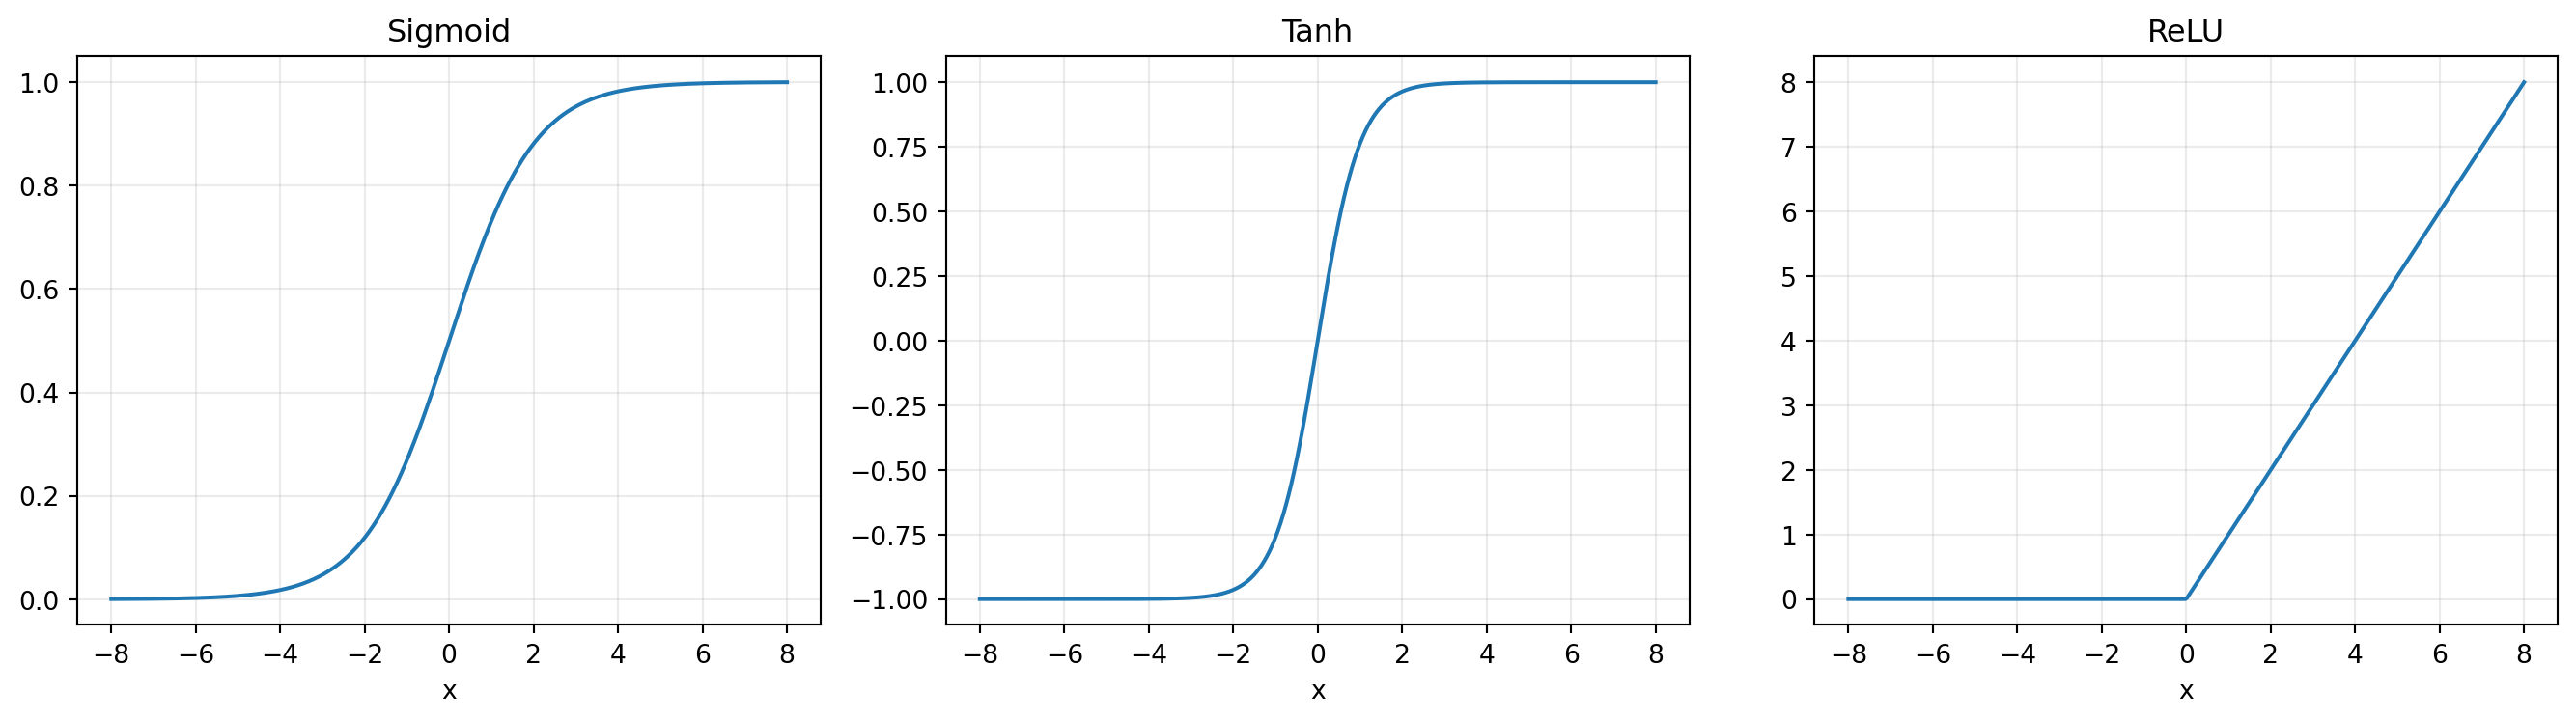

In [3]:
x = np.linspace(-8, 8, 500)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(x, sigmoid)
axes[0].set_title("Sigmoid")
axes[1].plot(x, tanh)
axes[1].set_title("Tanh")
axes[2].plot(x, relu)
axes[2].set_title("ReLU")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

In [4]:
logits = torch.tensor([[2.0, 1.0, 0.1], [0.5, 0.5, 0.5], [5.0, 1.0, -2.0]])
probs = torch.softmax(logits, dim=1)

print("logits:\n", logits)
print("softmax probabilities:\n", probs)
print("row sums:", probs.sum(dim=1))

logits:
 tensor([[ 2.0000,  1.0000,  0.1000],
        [ 0.5000,  0.5000,  0.5000],
        [ 5.0000,  1.0000, -2.0000]])
softmax probabilities:
 tensor([[6.5900e-01, 2.4243e-01, 9.8566e-02],
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [9.8114e-01, 1.7970e-02, 8.9468e-04]])
row sums: tensor([1.0000, 1.0000, 1.0000])


In [5]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1  # y = (x+1)^2

y.backward()
print("x:", x.item())
print("autograd dy/dx:", x.grad.item())
print("analytic dy/dx:", 2*x.item() + 2)

x: 3.0
autograd dy/dx: 8.0
analytic dy/dx: 8.0


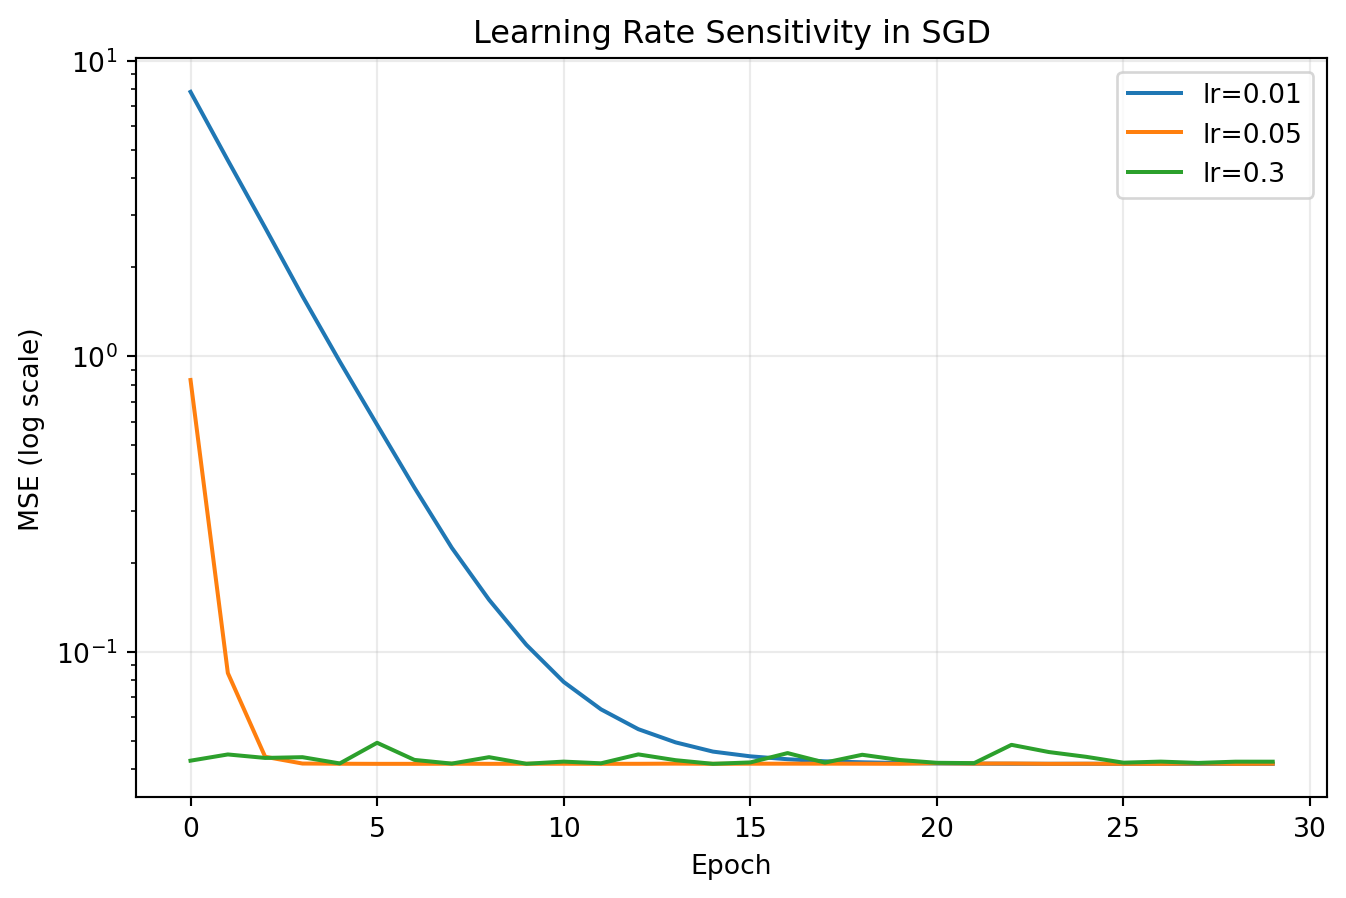

lr=0.01 -> w,b: 3.0 2.001
lr=0.05 -> w,b: 3.007 1.997
lr=0.30 -> w,b: 2.991 1.977


In [6]:
# Synthetic data: y = 3x + 2 + noise
n = 400
X = torch.randn(n, 1)
y = 3 * X + 2 + 0.2 * torch.randn(n, 1)

def train_sgd(lr=0.05, batch_size=32, epochs=30):
    w = torch.zeros((1, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X[idx], y[idx]

            pred = xb @ w + b
            loss = ((pred - yb)**2).mean()

            loss.backward()
            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()

        with torch.no_grad():
            full_loss = ((X @ w + b - y)**2).mean().item()
            losses.append(full_loss)
    return losses, w.detach().item(), b.detach().item()

losses_small, w_small, b_small = train_sgd(lr=0.01)
losses_mid, w_mid, b_mid = train_sgd(lr=0.05)
losses_large, w_large, b_large = train_sgd(lr=0.3)

plt.figure(figsize=(8, 5))
plt.plot(losses_small, label="lr=0.01")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_large, label="lr=0.3")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Learning Rate Sensitivity in SGD")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print("lr=0.01 -> w,b:", round(w_small, 3), round(b_small, 3))
print("lr=0.05 -> w,b:", round(w_mid, 3), round(b_mid, 3))
print("lr=0.30 -> w,b:", round(w_large, 3), round(b_large, 3))

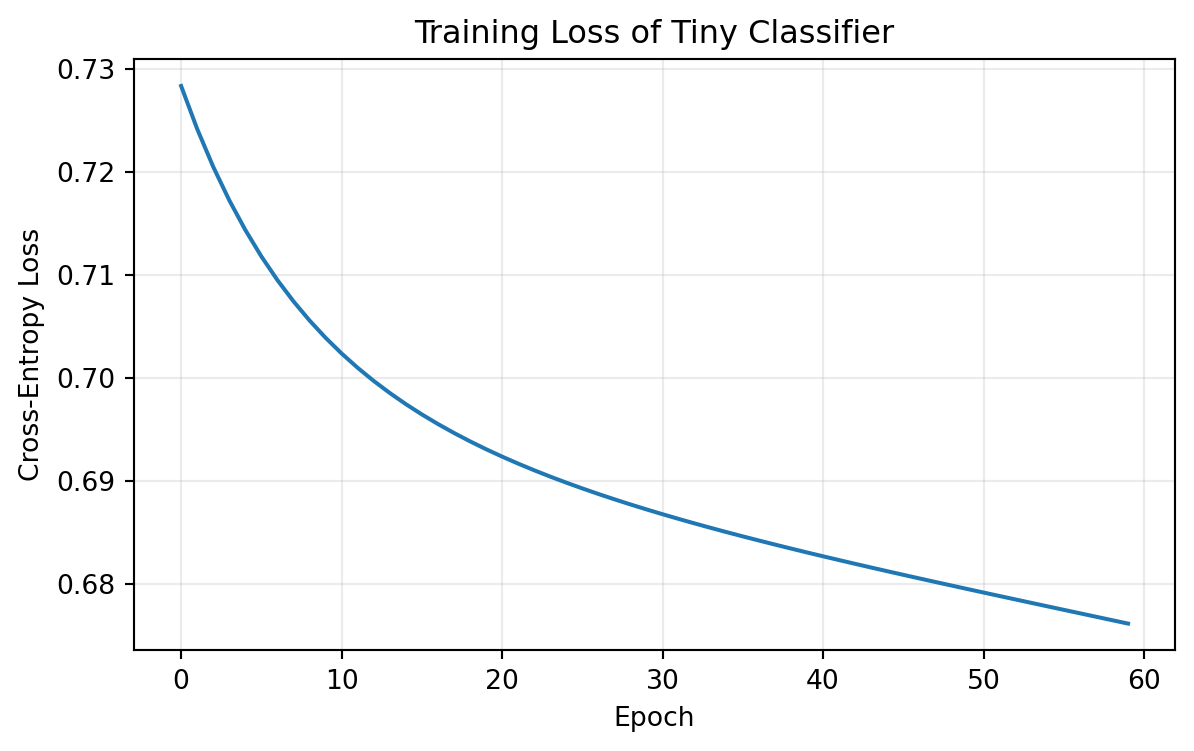

In [7]:
Xc = torch.randn(600, 2)
labels = (Xc[:, 0] * Xc[:, 1] > 0).long()  # nonlinear boundary

model = torch.nn.Sequential(
    torch.nn.Linear(2, 8),
    torch.nn.Tanh(),
    torch.nn.Linear(8, 2)
)

opt = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = torch.nn.CrossEntropyLoss()

history = []
for epoch in range(60):
    opt.zero_grad()
    logits = model(Xc)
    loss = loss_fn(logits, labels)
    loss.backward()
    opt.step()
    history.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.title("Training Loss of Tiny Classifier")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.25)
plt.show()